In [1]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import matplotlib.pyplot as plt

import matplotlib
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.converters import circuit_to_dag,dag_to_circuit

import sys
sys.path.append("../")
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, transform_qiskit_to_stim,generate_qiskit_param_map
from testing_scripts.qaoa_utils import QAOASolver
import testing_scripts.graphs_utils as graphs_utils

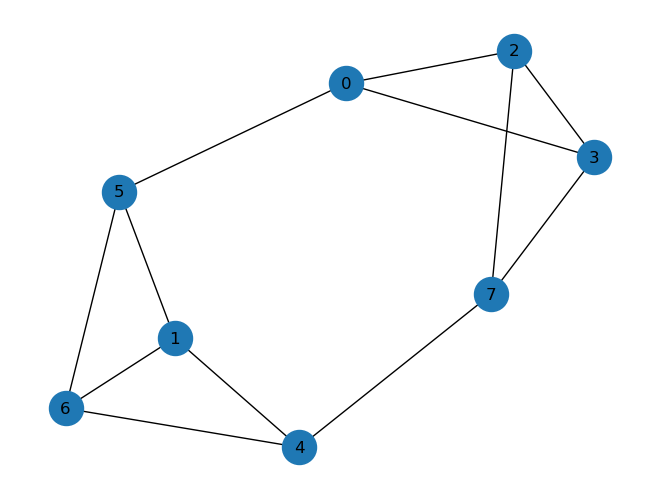

In [2]:
n = 8
k=3

G = graphs_utils.generate_k_regular_graph(num_vertices=n, k=k, weighted=True,seed=3)
# G=graphs_utils.generate_random_complete_graph(num_vertices=n, weighted=True, seed=2)
# G = graphs_utils.generate_random_ego_graph(num_nodes=n,weighted=True,seed=2)
# G = graphs_utils.generate_random_erdos_renyi_graph(num_nodes=n,probability=0.4,weighted=True,seed=4)
draw_graph(G, node_size=600, with_labels=True)

In [3]:
# Optimal Maxcut Calculation
# optimal_max_cut_val = graphs_utils.compute_optimal_max_cut(G)
# print(f"Optimal Max Cut Value : {optimal_max_cut_val}")

In [4]:

max_cut_paulis = graphs_utils.build_max_cut_paulis(G)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)
print(f"Number of terms : {len(cost_hamiltonian)}")

Cost Function Hamiltonian: SparsePauliOp(['ZIIIIZII', 'IIIZIIZI', 'ZIIIZIII', 'IIIIIZIZ', 'IZIZIIII', 'IIIIZIIZ', 'ZIIZIIII', 'IIZIIIZI', 'IIIIZZII', 'IZZIIIII', 'IIZIIIIZ', 'IZIIIIZI'],
              coeffs=[ 9.+0.j,  7.+0.j,  1.+0.j,  2.+0.j,  3.+0.j, 10.+0.j,  1.+0.j,  5.+0.j,
  1.+0.j,  3.+0.j,  1.+0.j,  3.+0.j])
Number of terms : 12


In [5]:
reps = 2
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)

In [6]:
maxcut_qaoa = QAOASolver(cost_hamiltonian,circuit,sim_device="CPU")
maxcut_qaoa.prepare_circuit()
maxcut_qaoa.err=None

/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/transpiler/passmanager.py:70: DeprecationWarning: The property ``qiskit.dagcircuit.dagcircuit.DAGCircuit.duration`` is deprecated as of qiskit 1.3.0. It will be removed in Qiskit 2.0.0.
  out_program = dag_to_circuit(passmanager_ir, copy_operations=False)
/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/transpiler/passmanager.py:70: DeprecationWarning: The property ``qiskit.dagcircuit.dagcircuit.DAGCircuit.unit`` is deprecated as of qiskit 1.3.0. It will be removed in Qiskit 2.0.0.
  out_program = dag_to_circuit(passmanager_ir, copy_operations=False)
/global/u1/d/dhanvib/development/QAOA/playground_scripts/../clapton/circuit_manipulation.py:211: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate = in

In [7]:
dag = circuit_to_dag(maxcut_qaoa.pcirc)
gate_types = list({node.name for node in dag.topological_op_nodes()})
print(gate_types)

['rz', 'sx', 'h', 'cx', 's']


In [8]:
assert len(maxcut_qaoa.stim_circ.gates) == maxcut_qaoa.pcirc.size()

In [9]:
#Run CAFQA process
maxcut_qaoa.run_CAFQA(n_gens=5)

STARTING ROUND 0




started GA at id 1 with 8 procs

started GA at id 2 with 8 procs
GA parameters used for this experiment:
  num_generations=2
  num_parents_mating=20
  population_size=100
  num_genes=40
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5
started GA at id None with 8 procs

GA parameters used for this experiment:
  num_generations=2
  num_parents_mating=20
  population_size=100
  num_genes=40
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5

started GA at id 3 with 8 procs

GA parameters used for this experiment:
  num_generations=2
  num_parents_mating=20
  population_size=100
  num_genes=40
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_prob

In [10]:
stim_circuit = maxcut_qaoa.stim_circ.assign(maxcut_qaoa.ks_best).stim_circuit()

In [11]:
from collections import Counter
# Sampling 
# Get the circuit and modify it *once*
circuit_m = stim_circuit
circuit_m.append_operation("M", list(range(n)))
sampler = circuit_m.compile_sampler()
samples = sampler.sample(shots=10000).astype(int)

# Step 3: Convert each row to a bitstring (MSB=qubit 0)
bitstrings = [''.join(map(str, sample)) for sample in samples]

# Step 4: Count and normalize
counts = Counter(bitstrings)
total = sum(counts.values())
probabilities = {k: v / total for k, v in counts.items()}

# Show distribution
sorted_probabilities = dict(sorted(probabilities.items(), key=lambda item: item[1], reverse=True))
print(sorted_probabilities)


{'11101100': 0.0181, '01111100': 0.018, '11001011': 0.0178, '00011101': 0.0174, '01011101': 0.0172, '01011001': 0.0172, '11001101': 0.0171, '01010111': 0.0171, '10101110': 0.017, '01010011': 0.0168, '01111010': 0.0168, '00110010': 0.0168, '11000111': 0.0167, '01011111': 0.0166, '10100110': 0.0165, '10001101': 0.0165, '00110000': 0.0165, '01110100': 0.0164, '10000001': 0.0164, '01011011': 0.0164, '00110100': 0.0163, '00010011': 0.0163, '10100100': 0.0162, '10101010': 0.0162, '10100010': 0.0161, '11100000': 0.0161, '00010101': 0.016, '11000101': 0.016, '11000001': 0.0159, '01111000': 0.0158, '00111000': 0.0157, '00011011': 0.0156, '10000011': 0.0156, '11000011': 0.0156, '00111110': 0.0156, '01010101': 0.0155, '01110000': 0.0154, '00010001': 0.0154, '11001001': 0.0153, '11101010': 0.0153, '00010111': 0.0152, '11101110': 0.0152, '11001111': 0.0152, '10000111': 0.0152, '11100110': 0.0151, '11101000': 0.0149, '10000101': 0.0149, '01010001': 0.0148, '11100100': 0.0147, '00110110': 0.0147, '10

In [12]:
top_k_bitstrings = list(sorted_probabilities.keys())

In [13]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import Initialize

statevec = np.zeros(2**n)
k = len(top_k_bitstrings)     
for s in top_k_bitstrings:
    idx = int(s, 2)
    statevec[idx] = 1/np.sqrt(k)
init_gate = Initialize(statevec)
init_circ = QuantumCircuit(n)
init_circ.append(init_gate, range(n))


In [14]:
from qiskit.circuit.library import StatePreparation
from qiskit.circuit import QuantumCircuit, Parameter
import numpy as np

# 1. Prepare normalized state vector (as before)
n = len(top_k_bitstrings[0])
statevec = np.zeros(2**n)
for s in top_k_bitstrings:
    idx = int(s, 2)
    statevec[idx] = 1/np.sqrt(len(top_k_bitstrings))

# 2. Use StatePreparation instead of Initialize (handles inverse better)
state_prep = StatePreparation(statevec)

# 3. Build mixer with manual inverse
beta = Parameter("β")
mixer = QuantumCircuit(n)

# Manually uncompute by reversing state preparation
for inst, qargs, cargs in reversed(state_prep.definition.data):
    mixer.append(inst.inverse(), qargs, cargs)

# Apply global X-rotations
for i in range(n):
    mixer.rx(2*beta, i)

# Re-prepare state
mixer.compose(state_prep, inplace=True)


/tmp/ipykernel_2095923/2578915145.py:20: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for inst, qargs, cargs in reversed(state_prep.definition.data):


In [15]:
# 5. Use in QAOA as before
ansatz = QAOAAnsatz(
    cost_operator=cost_hamiltonian,
    reps=reps,
    initial_state=init_circ,
    mixer_operator=mixer
)


In [16]:
vanilla_teague = QAOASolver(cost_hamiltonian,ansatz.decompose(reps=5),sim_device="CPU")
vanilla_teague.vanilla = True

/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/circuit/quantumcircuit.py:3278: DeprecationWarning: The property ``qiskit.dagcircuit.dagcircuit.DAGCircuit.duration`` is deprecated as of qiskit 1.3.0. It will be removed in Qiskit 2.0.0.
  return dag_to_circuit(dag, copy_operations=False)
/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/circuit/quantumcircuit.py:3278: DeprecationWarning: The property ``qiskit.dagcircuit.dagcircuit.DAGCircuit.unit`` is deprecated as of qiskit 1.3.0. It will be removed in Qiskit 2.0.0.
  return dag_to_circuit(dag, copy_operations=False)


In [17]:
import os
init_random_params = np.random.random(circuit.num_parameters)
res,obj_values=vanilla_teague.run_qaoa(init_random_params, max_iters=100)
results_dict = {
    "vanilla_fin_energy": res,
    "vanilla_iteration_values": obj_values,
}

/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit_aer/backends/aer_compiler.py:694: DeprecationWarning: The property ``qiskit.circuit.instruction.Instruction.condition`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  or getattr(inst.operation, "condition", None)
/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit_aer/backends/aer_compiler.py:730: DeprecationWarning: The property ``qiskit.circuit.instruction.Instruction.condition`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  if hasattr(inst.operation, "condition") and inst.operation.condition:
/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit_aer/backends/aer_compiler.py:694: DeprecationWarning: The property ``qiskit.circuit.instruction.Instruction.condition`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  or getattr(inst.operation, "condition", None)
/global/homes/d/dhanvib/.conda/

In [18]:
# ansatz.decompose(reps=5).draw('mpl')

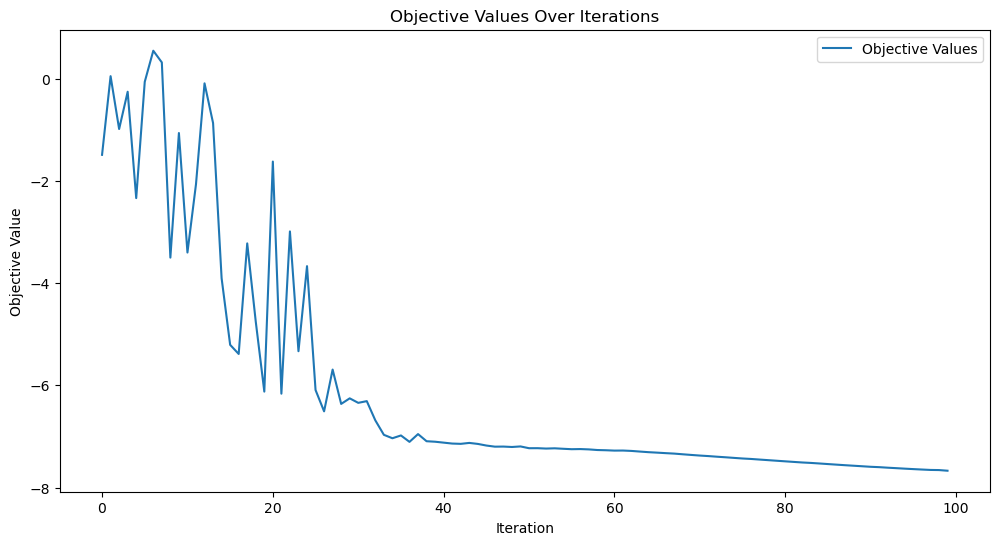

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(obj_values, label="Objective Values")
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title("Objective Values Over Iterations")
plt.legend()
plt.show()